### Outlier Detection


In [17]:

import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv('ipl_clean.csv')



/tmp/ipykernel_37669/2855115393.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


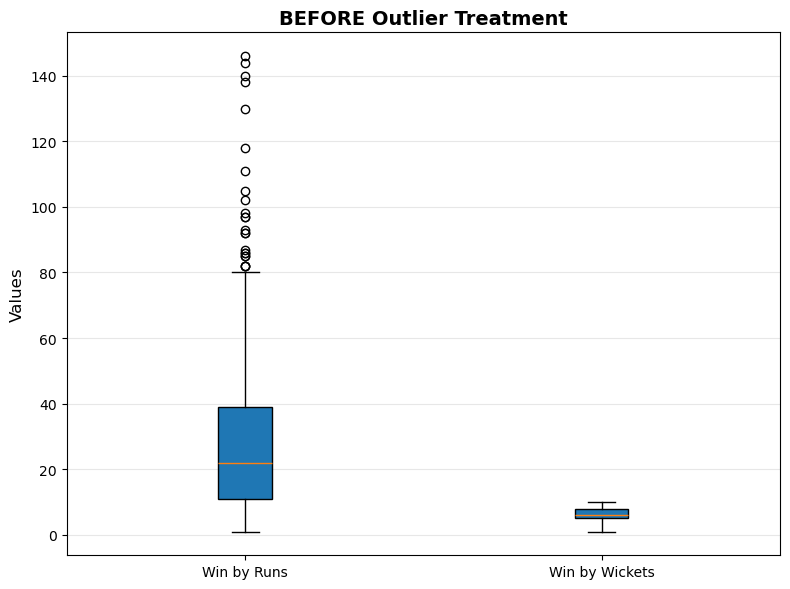

In [26]:


# BEFORE treatment
plt.figure(figsize=(8, 6))
plt.boxplot(
    [df_clean[df_clean['win_by_runs'] > 0]['win_by_runs'], 
     df_clean[df_clean['win_by_wickets'] > 0]['win_by_wickets']],
    labels=['Win by Runs', 'Win by Wickets'],
    patch_artist=True
)
plt.title('BEFORE Outlier Treatment', fontsize=14, fontweight='bold')
plt.ylabel('Values', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ipl_outliers_before.png', dpi=150)
plt.show()

In [27]:
# applyinh IQR fencing

def cap_outliers(column):
    Q1 = column.quantile(0.25)   # 25th percentile
    Q3 = column.quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # replacing values outside the fences with the fence values with clip function
    return column.clip(lower=lower_fence, upper=upper_fence)



In [28]:

# applying cap_outliers() to outlier columns
df_clean['win_by_runs_capped']    = cap_outliers(df_clean['win_by_runs'])
df_clean['win_by_wickets_capped'] = cap_outliers(df_clean['win_by_wickets'])

print("Outlier treatment done!")
print(f"win_by_runs    → max before: {df_clean['win_by_runs'].max()},  "
      f"max after: {df_clean['win_by_runs_capped'].max()}")
print(f"win_by_wickets → max before: {df_clean['win_by_wickets'].max()}, "
      f"max after: {df_clean['win_by_wickets_capped'].max()}")



Outlier treatment done!
win_by_runs    → max before: 146,  max after: 47.5
win_by_wickets → max before: 10, max after: 10


/tmp/ipykernel_37669/2318842615.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


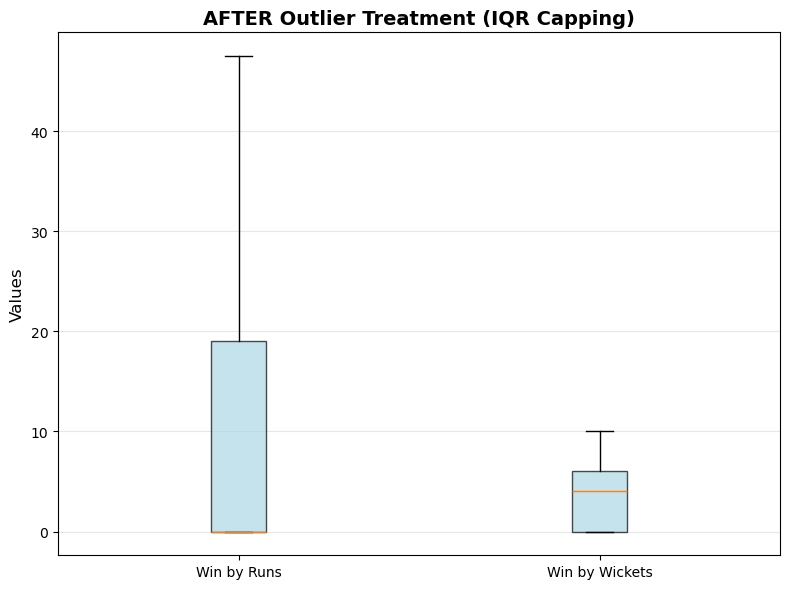

In [ ]:


# -----------------------------------------------
# AFTER treatment boxplot (separate figure)
# -----------------------------------------------
plt.figure(figsize=(8, 6))
plt.boxplot(
    [df_clean['win_by_runs_capped'], df_clean['win_by_wickets_capped']],
    labels=['Win by Runs', 'Win by Wickets'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7)
)
plt.title('AFTER Outlier Treatment (IQR Capping)', fontsize=14, fontweight='bold')
plt.ylabel('Values', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ipl_outliers_after.png', dpi=150)
plt.show()
# Save updated data
df_clean.to_csv('ipl_clean.csv', index=False)